---
tags:
  - sparse-differentiation
  - mixed-element
  - lifter
---

# Peeling of a dimpled adhesive beam via Lagrange Multipliers

This example demonstrates how to model the peeling process of an elastic beam from a rigid substrate. It showcases the use of Lagrange multipliers to enforce contact constraints and an active set strategy to model the progressive failure of adhesive bonds.

**Key Technical Concepts**

* Nonlinear Elasticity: The beam is modeled using a 2D plane-stress Neo-Hookean material law, accounting for large deformations during the peeling process.
* Lagrange Multipliers: Instead of penalty methods, we use Lagrange multipliers to strictly enforce the zero-displacement constraint on the adhesive interface. These multipliers physically represent the (negative) pressure at the bond.
* Active Set Strategy: The "peeling" is governed by a strength-based criterion. An iterative loop manages the "active set" of constraints, releasing nodes where the Lagrange multiplier exceeds a critical adhesive strength.
* Rigid Body Coupling: A Lifter constraint is used to couple a set of boundary nodes to a single rigid-body motion (translation and rotation), simulating a stiff loading handle.
* Structured State Management: The tatva.compound module is used to define a complex solution space containing the rigid body displacement, the nodal displacement field, and the Lagrange multipliers.
* Efficient Sparse JAX Solvers: We utilize custom sparsity patterns and the SparseTatva linear solver to perform efficient Newton iterations on the constrained system.

**Problem Setup**

A notched beam is adhered to a substrate along its bottom edge. The left end of the beam is pulled upwards by a rigid handle. As the load increases, the stress concentrates at the "peel front." Once the adhesive strength is reached, the constraint is deactivated, the bond "breaks," and the peel front advances.

In [296]:
from dataclasses import replace
from typing import Literal, NamedTuple, Callable

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sps
from jax import Array
from jax_autovmap import autovmap

from tatva import Mesh, Operator, compound, sparse
from tatva.element.base import Line2, Tri3
from tatva.lifter import Constraint, Fixed, Lifter, RuntimeValue

jax.config.update("jax_enable_x64", True)


def jit[**P, T](f: Callable[P, T], *args, **kwargs) -> Callable[P, T]:
    return jax.jit(f, *args, **kwargs)


def jacrev[**P, T](f: Callable[P, T], *args, **kwargs) -> Callable[P, T]:
    return jax.jacrev(f, *args, **kwargs)

## Meshing

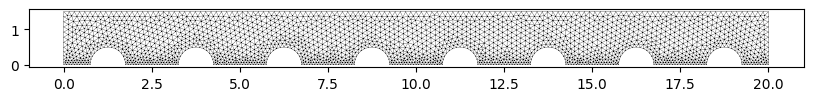

In [ ]:
# [collapse: code] Code to generate a notched beam mesh using Gmsh, extract nodes and elements, and plot the mesh.

import gmsh
from contextlib import contextmanager


@contextmanager
def gmsh_context():
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    try:
        yield
    finally:
        gmsh.finalize()


def generate_notched_beam(
    length=10.0, height=2.0, num_notches=4, notch_radius=0.8, hmin=0.01, hmax=0.2
):
    gmsh.model.add("NotchedBeam")

    # 1. Create the main beam (Rectangle)
    beam = gmsh.model.occ.addRectangle(0, 0, 0, length, height)

    # 2. Create the notches
    notch_disks = []
    spacing = length / num_notches
    x_pos_0 = spacing / 2
    for i in range(num_notches):
        x_pos = x_pos_0 + i * spacing
        disk = gmsh.model.occ.addDisk(x_pos, 0, 0, notch_radius, notch_radius)
        notch_disks.append((2, disk))

    # 3. Boolean Subtraction
    # Note: 'cut' returns a tuple; the first element is the list of remaining surfaces
    out, out_map = gmsh.model.occ.cut([(2, beam)], notch_disks)
    gmsh.model.occ.synchronize()

    # --- 4. MESH REFINEMENT FIELDS ---

    # Get all boundary curves (1D) to calculate distance from
    # These will be the circular arcs created by the cut
    boundary_curves = gmsh.model.getBoundary(
        out, combined=True, oriented=False, recursive=False
    )

    notch_curve_tags = []
    bottom_curve_tags = []
    for dim, tag in boundary_curves:
        # Get the bounding box of the curve [xmin, ymin, zmin, xmax, ymax, zmax]
        bbox = gmsh.model.getBoundingBox(dim, tag)
        ymax = bbox[4]

        # If the highest point of the curve is close to the notch_radius height
        # and the lowest point is at 0, it's a notch.
        # (Standard beam edges are either at y=0, y=height, or vertical)
        if ymax <= (notch_radius + 1e-3) and ymax > 1e-3:
            notch_curve_tags.append(tag)
        elif ymax <= 1e-3:
            bottom_curve_tags.append(tag)

    # Field 1: Distance from the notch boundaries
    f_dist = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist, "CurvesList", notch_curve_tags)
    gmsh.model.mesh.field.setNumber(f_dist, "Sampling", 100)
    f_dist_bottom = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist_bottom, "CurvesList", bottom_curve_tags)
    gmsh.model.mesh.field.setNumber(f_dist_bottom, "Sampling", 100)

    # Field 2: Threshold - map distance to element size
    f_thresh = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thresh, "InField", f_dist)
    gmsh.model.mesh.field.setNumber(f_thresh, "SizeMin", hmin * 1.5)
    gmsh.model.mesh.field.setNumber(f_thresh, "SizeMax", hmax)
    gmsh.model.mesh.field.setNumber(f_thresh, "DistMin", 0.05)
    gmsh.model.mesh.field.setNumber(f_thresh, "DistMax", 0.5)

    f_thresh_bottom = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thresh_bottom, "InField", f_dist_bottom)
    gmsh.model.mesh.field.setNumber(f_thresh_bottom, "SizeMin", hmin * 1)
    gmsh.model.mesh.field.setNumber(f_thresh_bottom, "SizeMax", hmax)
    gmsh.model.mesh.field.setNumber(f_thresh_bottom, "DistMin", 0.05)
    gmsh.model.mesh.field.setNumber(f_thresh_bottom, "DistMax", 0.5)

    f_min = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(f_min, "FieldsList", [f_thresh, f_thresh_bottom])

    # Set this as the background mesh field
    gmsh.model.mesh.field.setAsBackgroundMesh(f_min)

    # Gmsh doesn't use the global min/max options if a field is active
    # unless you explicitly tell it to respect them:
    gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
    gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)
    gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)

    # Generate
    gmsh.model.mesh.generate(2)


def extract_mesh_data():
    """
    Extracts nodes and triangular element connectivity from the current Gmsh model.
    Returns:
        nodes: (N, 3) array of [x, y, z] coordinates
        elements: (M, 3) array of node indices (zero-based) for triangles
    """
    # 1. Get Nodes
    # nodeTags: unique ID for each node
    # coords: flat list [x1, y1, z1, x2, y2, z2, ...]
    node_tags, coords, _ = gmsh.model.mesh.getNodes()

    # Reshape coordinates into (N, 3) array
    nodes = np.array(coords).reshape(-1, 3)

    # Create a mapping from Gmsh nodeTag to 0-based array index
    # (Gmsh tags often start at 1 and may not be contiguous)
    node_map = {tag: i for i, tag in enumerate(node_tags)}

    # 2. Get Elements (Triangles)
    # 2 is the Gmsh element type for a 3-node triangle
    elem_types, elem_tags, elem_node_tags = gmsh.model.mesh.getElements(dim=2)

    # Find the index of the 3-node triangle type in the returned lists
    # Note: elem_types is a list of types present in the mesh
    try:
        tri_idx = list(elem_types).index(2)
        tri_node_tags = elem_node_tags[tri_idx]
    except ValueError:
        print("No triangular elements (type 2) found in the mesh.")
        return nodes, np.array([])

    # 3. Convert connectivity to 0-based indices using our map
    # Reshape to (M, 3) since each triangle has 3 nodes
    tri_node_tags = tri_node_tags.reshape(-1, 3)
    elements = np.array([[node_map[tag] for tag in row] for row in tri_node_tags])

    return nodes, elements


l = 20.0
h = 1.5

with gmsh_context():
    generate_notched_beam(
        length=l, height=h, num_notches=8, notch_radius=0.5, hmax=0.15, hmin=0.075
    )
    nodes, elements = extract_mesh_data()


fig, ax = plt.subplots(figsize=(10, 4))
ax.set_aspect("equal")
ax.triplot(nodes[:, 0], nodes[:, 1], elements, color="k", lw=0.2)

## Problem setup

### Material law

In [347]:
class Material(NamedTuple):
    """Material properties for the elasticity operator."""

    mu: float  # Diffusion coefficient
    lmbda: float  # Diffusion coefficient

    @classmethod
    def from_youngs_poisson_2d(
        cls, E: float, nu: float, plane_stress: bool = False
    ) -> "Material":
        mu = E / 2 / (1 + nu)
        if plane_stress:
            lmbda = 2 * nu * mu / (1 - nu)
        else:
            lmbda = E * nu / (1 - 2 * nu) / (1 + nu)
        return cls(mu=mu, lmbda=lmbda)


@autovmap(grad_u=2)
def compute_deformation_gradient(grad_u: Array) -> Array:
    return jnp.eye(2) + grad_u


@autovmap(grad_u=2, mat=None)
def strain_energy_density(grad_u: Array, mat: Material) -> Array:
    F = compute_deformation_gradient(grad_u)
    C = F.T @ F
    J = jnp.linalg.det(F)
    return (
        mat.mu / 2 * (jnp.trace(C) - 2)  # 2D case
        - mat.mu * jnp.log(J)
        + (mat.lmbda / 2) * (jnp.log(J)) ** 2
    )


@autovmap(grad_u=2, mat=None)
def get_cauchy_stress(grad_u: Array, mat: Material) -> Array:
    F = compute_deformation_gradient(grad_u)
    C = F.T @ F
    J = jnp.linalg.det(F)

    C_inv = jnp.linalg.inv(C)
    S = mat.mu * (jnp.eye(2) - C_inv) + mat.lmbda * jnp.log(J) * C_inv  # 2nd PK
    P = F @ S  # 1st PK

    sigma = (P @ F.T) / J  # Cauchy
    return sigma


def von_mises_stress(sig):
    s_xx, s_yy, s_xy = sig[..., 0, 0], sig[..., 1, 1], sig[..., 0, 1]
    return np.sqrt(s_xx**2 - s_xx * s_yy + s_yy**2 + 3 * s_xy**2)


### Operator & Compound definition

In [348]:
mesh = Mesh(jnp.asarray(nodes[:, :2]), jnp.asarray(elements))

bottom_nodes = jnp.where((mesh.coords[:, 1] == 0) & (mesh.coords[:, 0] > 1))[0]
# bottom_nodes = jnp.where(mesh.coords[:, 1] == 0)[0]
load_nodes = jnp.where(mesh.coords[:, 0] == 0)[0]
# we fix the bottom right corner to prevent rigid body motion when fully cracked
right_bottom = jnp.where((mesh.coords[:, 0] == l) & (mesh.coords[:, 1] == 0))[0]

# the line elements are those that have at least 2 nodes on the bottom boundary, and all
# of their nodes have y=0
line_element_indices = jnp.where(
    sum(
        jnp.isin(mesh.elements[:, dim], bottom_nodes)
        for dim in range(mesh.elements.shape[1])
    )
    >= 2
)[0]
line_elements = mesh.elements[line_element_indices]
mask_y_is_zero = mesh.coords[line_elements][..., 1] == 0
line_elements = line_elements[mask_y_is_zero].reshape(-1, 2)

op = Operator(mesh, Tri3())
op_line = Operator(replace(mesh, elements=line_elements), Line2())
mat = Material.from_youngs_poisson_2d(1, 0.3)


class Solution(compound.Compound):
    u_rigid = compound.field((3,))
    """x, y displacement of the rigid body"""
    u = compound.field((mesh.coords.shape))
    """Displacement field (u_x, u_y) at each node"""
    lm = compound.field((op_line.mesh.elements.shape[0],))  # DG space
    """Lagrange-multipliers for y-displacement at bottom nodes"""


Solution.size

4562

### Lifter definition

In [349]:
class RigidBody(Constraint):
    """Constraint to enforce rigid body motion on a set of nodes."""

    def __init__(self, rigid_nodes: Array, x_ref: Array):
        self.dofs = Solution.u[rigid_nodes, :].flatten()
        self.rigid_nodes = rigid_nodes
        self.x_ref = x_ref

    def apply_lift(self, u_full: Array) -> Array:
        sol = Solution(u_full)
        u, u_rigid = sol.u, sol.u_rigid
        u_after_constraint = self.constraint_function(u_rigid, u)

        return sol.at("u").set(u_after_constraint).at("u_rigid").set(u_rigid).flatten()

    def constraint_function(self, u_rigid: Array, u: Array) -> Array:
        """Takes u_rigid and computes the constraint u_flat
        fn (3,) -> (self.dofs.size,)
        """
        vecs = mesh.coords[self.rigid_nodes] - self.x_ref
        ux, uy, theta = u_rigid
        cos, sin = jnp.cos(theta), jnp.sin(theta)
        rotation_matrix = jnp.array([[cos, -sin], [sin, cos]])
        rotated_vecs = vecs @ rotation_matrix.T
        u_rotation = rotated_vecs - vecs
        u_rigid = jnp.stack([ux, uy]) + u_rotation
        return u.at[self.rigid_nodes, :].set(u_rigid)


rigid_body_constraint = RigidBody(load_nodes, jnp.array([0.0, h / 2]))
lifter = Lifter(
    Solution.size,
    Fixed(Solution.u[right_bottom, 0]),
    Fixed(Solution.u_rigid[1], RuntimeValue("disp", default=0.0)),
    rigid_body_constraint,
)

### Energy functional

The equilibrium state of the peeling beam is found by stationarity of a total Lagrangian functional $\mathcal{L}$, which combines the internal strain energy of the beam with the potential energy of the adhesive constraints.

The functional is defined as:
$$\mathcal{L}(\mathbf{u}, \boldsymbol{\lambda}) = \int_{\Omega} \psi(\nabla \mathbf{u}) \, d\Omega + \int_{\Gamma_c} g(u_y, \lambda, \mathcal{A}) \, d\Gamma$$

Where:
* Strain Energy Density ($\psi$): Represents the hyperelastic response of the material (in this example, a Neo-Hookean model).
* Contact Interface ($\Gamma_c$): The boundary where the beam is adhered to the substrate.
* Constraint Potential ($g$): This term enforces the adhesion using the active set $\mathcal{A}$. It is defined piecewise as:
  $$g = \begin{cases} \lambda \cdot u_y & \text{if } \text{node} \in \mathcal{A} \quad \text{(Bonded)} \\ \frac{1}{2} \lambda^2 & \text{if } \text{node} \notin \mathcal{A} \quad \text{(Released)} \end{cases}$$

**Why the quadratic term for released nodes?**

When a node is released from the active set, the constraint $u_y = 0$ no longer applies. However, the Lagrange multiplier $\lambda$ remains a variable in our system. By adding the $\frac{1}{2}\lambda^2$ term for inactive constraints, we ensure that:
1. The stationarity condition $\frac{\partial \mathcal{L}}{\partial \lambda} = \lambda = 0$ naturally drives the force at the released element to zero.
2. The global Hessian matrix remains well-conditioned and invertible, as every multiplier has a unit entry in the "stiffness" matrix.

In [350]:
def equality_constraint_potential(lm: Array, u: Array, active_set: Array) -> Array:
    density = jnp.where(
        active_set[..., None],
        lm[..., None] * op_line.eval(u)[..., 1],
        0.5 * lm[..., None] ** 2,
    )
    return op_line.integrate(density)


def total_lagrangian(z: Array, active_set: Array, mat: Material = mat) -> Array:
    u_rigid, u, lm = Solution(z)

    # strain energy contribution
    psi = strain_energy_density(op.grad(u), mat)
    Psi = op.integrate(psi)

    # constraint contribution
    G = equality_constraint_potential(lm, u, active_set)
    return Psi + G


def total_lagrangian_lifted(
    z_reduced: Array, active_set: Array, lifter: Lifter, mat: Material = mat
) -> Array:
    z_full = lifter.lift_from_zeros(z_reduced)
    return total_lagrangian(z_full, active_set, mat)


### Sparsity definition

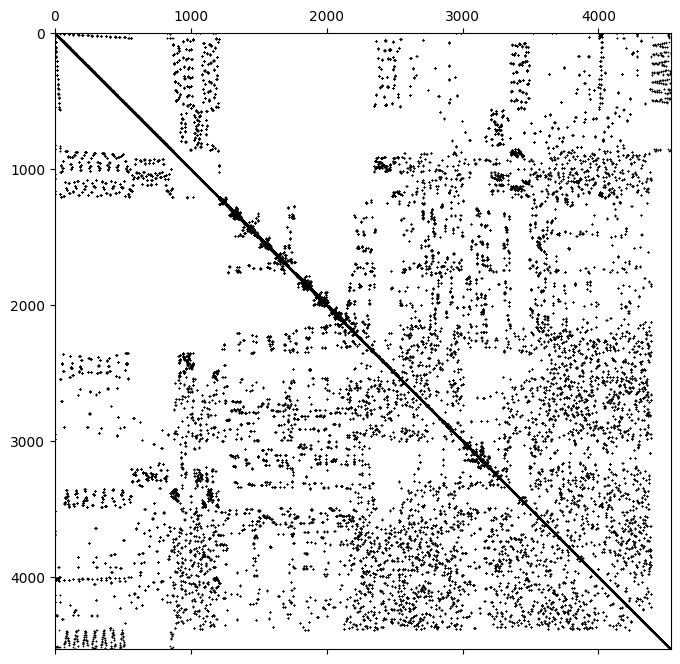

In [351]:
u_rigid, u, lm = Solution()
active_set = jnp.ones_like(lm, dtype=bool)  # all constraints active for now

# We use jacrev to get the gradient w.r.t. lm, and jacfwd to get the Jacobian w.r.t. u.
g_fn = jax.jacrev(lambda lm, u: equality_constraint_potential(lm, u, active_set))
# B_fn will give us the coupling Jacobian (shape=(num_constraints, num_dofs))
# need to flatten u for jacfwd and then reshape inside the lambda
B_fn = jax.jacfwd(
    lambda lm, u: g_fn(lm, u.reshape(Solution.u.shape)).flatten(), argnums=1
)
B = sps.csr_matrix(B_fn(lm, u.flatten()))

# these are the block-diagonal stiffness matrices for the rigid body, the displacement field, and the Lagrange multipliers
K_rigid = sps.csr_matrix(jnp.ones((3, 3)))
K_u = sparse.create_sparsity_pattern(mesh, 2)
K_lm = sps.eye(Solution.lm.size, format="csr")

# create a 'Mask' matrix that represents which nodes the rigid body 'touches'
# Shape: (Total_DOFs, 3)
B_pattern = sps.lil_matrix((Solution.u.size, 3))
B_pattern[rigid_body_constraint.rigid_nodes * 2] = 1
B_pattern[rigid_body_constraint.rigid_nodes * 2 + 1] = 1
B_pattern = B_pattern.tocsr()

# The coupling actually extends to anyone connected to a rigid node.
# We find this by multiplying the mesh connectivity by our rigid mask.
# (Mesh_Sparsity) @ (Rigid_Mask) gives the "influence zone"
extended_coupling_pattern = (K_u != 0) @ B_pattern
B_rigid = extended_coupling_pattern.tocsr()

block_matrix = [
    [K_rigid, B_rigid.T, None],
    [B_rigid, K_u, B.T],
    [None, B, K_lm],
]

sparsity_pattern = sps.bmat(block_matrix, format="csr")
sparsity_pattern = sparse.reduce_sparsity_pattern(sparsity_pattern, lifter.free_dofs)

# finally, color the matrix for sparse differentiation
colored_matrix = sparse.ColoredMatrix.from_csr(sparsity_pattern)

fig, ax = plt.subplots(figsize=(10, 8))
ax.spy(sparsity_pattern, markersize=0.3, color="k")

### Residual & Hessian

In [352]:
residual_fn = jit(jacrev(total_lagrangian_lifted))
residual_fn_full = jit(jacrev(total_lagrangian))

jacobian_fn = jit(sparse.jacfwd(residual_fn, colored_matrix=colored_matrix))

## Solve

!!! note
    In this example we use [bamboost](https://github.com/smec-ethz/bamboost) to store the results. `bamboost` is a zero-setup scientific data storage system that is easy to use but also scales. You can find it here https://github.com/smec-ethz/bamboost.
    
    Furthermore we use `soldis` (which provides a simple NR solver).

In [ ]:
from bamboost import Collection

coll = Collection("data")
coll = coll.filter(tags="adhesion")
sim = coll.add("adhesion_example", tags={"adhesion", "with_sig"})
sim.meshes.add(mesh.coords, mesh.elements)

In [355]:
from typing import TypeAlias

from jax.experimental import checkify
from soldis import linear, newton
from soldis.newton import SolverState
from tatva.utils import make_project_function

Carry: TypeAlias = tuple[int, Array, SolverState[Array], Array]

solver = newton.NewtonSolver(
    residual_fn,
    linear.SparseTatva(),
    jacobian_fn,
    options=newton.NewtonSolverOptions(maxiter=50, tol=1e-10, verbose=False),
)

# initial guesses
y0 = jnp.zeros(lifter.size_reduced)
active_set = jnp.ones(Solution.lm.size, dtype=bool)  # all constraints active for now

# adhesive strength
strength = 1e-1

solver.root = jit(solver.root)
initial_state = solver.init(y0, active_set, lifter, mat)

project = make_project_function(mesh.coords.shape[0], elements=mesh.elements)


@jit
@checkify.checkify
def solve_with_active_set(
    state: SolverState[Array],
    active_set: Array,
    lifter: Lifter,
    mat: Material,
    strength: float,
) -> tuple[Array, SolverState[Array]]:

    carry: Carry = (0, active_set, state, jnp.asarray(False))

    def cond_fun(carry: Carry) -> Array:
        *_, converged = carry
        # continue as long as NOT converged
        return jnp.logical_not(converged)

    def body_fun(carry: Carry) -> Carry:
        i, active_set, _state, converged = carry

        jax.debug.print("    Active set loop iteration {}", i)

        sol = solver.root(_state.value, active_set, lifter, mat)
        checkify.check(
            sol.residual_norm < 1e-5,
            "Solver did not converge within the body of the loop",
        )
        lm = Solution(lifter.lift_from_zeros(sol.value)).lm
        new_active_set = active_set * (lm <= strength)
        # max_lm = jnp.argmax(lm)
        # new_active_set = active_set.at[max_lm].set(lm[max_lm] <= strength)

        # Check for convergence: has the active set stopped changing?
        converged = jnp.array_equal(new_active_set, active_set)

        return (i + 1, new_active_set, sol, converged)

    final_i, final_active_set, final_state, _ = jax.lax.while_loop(
        cond_fun, body_fun, carry
    )

    return final_active_set, final_state


d_previous = 0.0
state = initial_state
_lifter = lifter


def step(
    i: int,
    d: float,
    d_previous: float,
    state: SolverState[Array],
    active_set: Array,
    _lifter: Lifter,
):
    active_set_backup = active_set
    state_backup = state

    print(f"--> Solving for displacement: {d:.2f}")
    _lifter = _lifter.at("disp").set(d)
    err, (active_set, state) = solve_with_active_set(
        state, active_set, _lifter, mat, strength
    )
    # err.throw()

    if err.get() is not None:
        # solve at an intermediate displacement to get a better solution
        _lifter = _lifter.at("disp").set(d_previous + (d - d_previous) / 2)
        err, (active_set, state) = solve_with_active_set(
            state_backup, active_set_backup, lifter, mat, strength
        )
        err.throw()
        # solve again at the original displacement to get the correct active set for post-processing
        _lifter = _lifter.at("disp").set(d)
        err, (active_set, state) = solve_with_active_set(
            state_backup, active_set_backup, lifter, mat, strength
        )

    print(f"    Residual after solve: {state.residual_norm:.2e} [{state.iteration}]")
    d_previous = d

    # compute the reaction force at the loaded nodes using the full residual function
    _lifter = _lifter.at("disp").set(d)
    force_value = residual_fn_full(
        _lifter.lift_from_zeros(state.value), active_set, mat
    )[Solution.u[load_nodes, 1]].sum()

    # finally, write the results to the simulation
    u_rigid, u, lm = Solution(_lifter.lift_from_zeros(state.value))

    if i % 1 == 0:
        s = sim.data.require_step(d)
        s.add_field("u", u)
        s.add_field("u_rigid", u_rigid)
        s.add_field("lm", lm)
        s.add_field("active_set", active_set)
        sig = get_cauchy_stress(op.grad(u), mat)
        sig_vm = von_mises_stress(sig)
        # sig_vm_nodal = project(op, sig_vm)
        s.add_field("sig_vm", sig_vm)
        s.add_scalar("force", force_value)
    return d_previous, state, active_set, _lifter


In [ ]:
for i, d in enumerate(jnp.arange(0, 14, 0.05)):
    d_previous, state, active_set, _lifter = step(
        i, d, d_previous, state, active_set, _lifter
    )

In [ ]:
# After the solver fails, we continue solving with a smaller increment
# We do this manually here, because we can do that flexibly in a notebook setting. Would have to be automated in a script.
# Continue from previous solution
last_step = sim.data.last_step or 0
y_now = (
    Solution()
    .at("u")
    .set(sim.data["u"][last_step])
    .at("u_rigid")
    .set(sim.data["u_rigid"][last_step])
    .at("lm")
    .set(sim.data["lm"][last_step])
    .arr
)
y_now = lifter.reduce(y_now)
state = solver.init(y_now, sim.data["active_set"][last_step], lifter, mat)
d_previous = sim.data.values[last_step]
active_set = sim.data["active_set"][last_step]

increment = 0.02
while True:
    d_previous, state, active_set, _lifter = step(
        0, d_previous + increment, d_previous, state, active_set, _lifter
    )
    if d_previous > 13.5:
        break

## Results

13.429999999999884


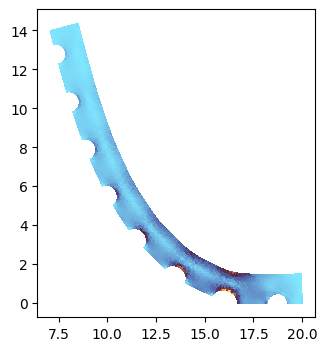

In [ ]:
from matplotlib.tri import Triangulation

i = -5
print(sim.data.values[i])
u, lm, active_set = (
    sim.data["u"][i],
    sim.data["lm"][i],
    sim.data["active_set"][i],
)
sig_vm = sim.data["sig_vm"][i].squeeze()

tri = Triangulation(mesh.coords[:, 0], mesh.coords[:, 1], mesh.elements)
x, y = mesh.coords[:, 0] + u[:, 0], mesh.coords[:, 1] + u[:, 1]

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_aspect("equal")
ax.tripcolor(x, y, mesh.elements, sig_vm, cmap="managua_r")

[Text(0.5, 0, 'Applied Displacement'), Text(0, 0.5, 'Reaction Force')]

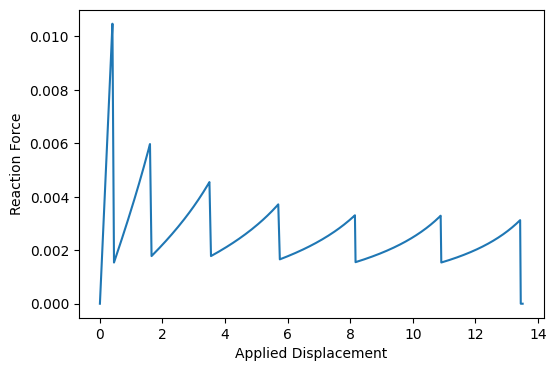

In [371]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(sim.data.values, sim.data.globals["force"][:], "-")
ax.set(xlabel="Applied Displacement", ylabel="Reaction Force")

### Animation

In [ ]:
total_steps = len(sim.data.values)
indices = np.arange(total_steps)
n_frames = 150
equidistant_loading = np.linspace(0.0, sim.data.values[-1], n_frames)
sampled_float_indices = np.interp(equidistant_loading, sim.data.values, indices)
sampled_indices = np.unique(np.round(sampled_float_indices).astype(int))
sampled_indices = sampled_indices.tolist()

In [ ]:
# [collapse: code] Code to create an animation of the deformation and stress distribution over time, along with the force-displacement curve.

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.tri import Triangulation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# 1. Setup the Figure and Axes
fig, (ax_stress, ax_force) = plt.subplots(1, 2, figsize=(12, 4.5))

# Pre-calculate triangulation (topology doesn't change, only coordinates)
tri = Triangulation(mesh.coords[:, 0], mesh.coords[:, 1], mesh.elements)

# Extract Force/Displacement data for the right plot
displacements = sim.data.values
forces = sim.data.globals["force"][:]

# 2. Initialize the Right Plot (Force-Displacement)
(past_curve,) = ax_force.plot(
    [], [], "-", color="k", alpha=0.5, label="Response History"
)
(curr_point,) = ax_force.plot([], [], "ro", markersize=8, label="Current State")
ax_force.set_xlabel("Applied Displacement")
ax_force.set_ylabel("Reaction Force")
# ax_force.legend()
ax_force.grid(True, linestyle="--", alpha=0.6)

cbar = None
sig_max = 0.15
sig_min = 0.0


def update(i):
    global cbar
    ax_stress.clear()

    u_i = sim.data["u"][i]
    sig_vm = sim.data["sig_vm"][i].squeeze()

    x_def = mesh.coords[:, 0] + u_i[:, 0]
    y_def = mesh.coords[:, 1] + u_i[:, 1]

    tpc = ax_stress.tripcolor(
        x_def,
        y_def,
        mesh.elements,
        sig_vm,
        cmap="managua_r",
        # shading="gouraud",
        vmax=sig_max,
        vmin=sig_min,
    )
    ax_stress.axhspan(-1, 0, color="0", hatch="///", alpha=0.2)

    ax_stress.set_aspect("equal")
    ax_stress.set(ylim=(-1, 16), xlim=(-1, 21))

    u_rigid = sim.data["u_rigid"][i]
    x_ref = np.array([0.0, h / 2])
    cos, sin = np.cos(u_rigid[2]), np.sin(u_rigid[2])
    rot = np.array([[cos, -sin], [sin, cos]])
    p1_ref = np.array([0.0, 0.0])
    p2_ref = np.array([0.0, h])
    p1 = x_ref + u_rigid[:2] + rot @ (p1_ref - x_ref)
    p2 = x_ref + u_rigid[:2] + rot @ (p2_ref - x_ref)
    ax_stress.plot([p1[0], p2[0]], [p1[1], p2[1]], "k-", linewidth=2)
    ax_stress.arrow(x_ref[0] + u_rigid[0], x_ref[1] + u_rigid[1], 0, 1, head_width=0.3, head_length=0.3, fc="k", ec="k")  # fmt: off
    ax_stress.text(
        p2[0] + 0.2,
        p2[1],
        "$u_y = {:.2f}$".format(u_rigid[1]),
        fontsize=8,
        verticalalignment="bottom",
    )

    if cbar is None:
        # width: 30% of parent, height: 5% of parent
        cax = inset_axes(
            ax_stress,
            width="2%",
            height="50%",
            loc="upper right",
            bbox_to_anchor=(0, 0, 0.9, 1),
            bbox_transform=ax_stress.transAxes,
            borderpad=2,
        )
        cbar = fig.colorbar(tpc, cax=cax, orientation="vertical")
        cbar.set_label("$\sigma_{vm}$", size=10)
        cax.xaxis.set_ticks_position("bottom")

    curr_point.set_data([displacements[i]], [forces[i]])
    past_curve.set_data(displacements[: i + 1], forces[: i + 1])
    ax_force.set_xlim(0, displacements[i] * 1.1)
    ax_force.set_ylim(0, max(forces) * 1.1)

    return tpc, curr_point


ani = FuncAnimation(fig, update, frames=sampled_indices, interval=100, blit=False)
# update(-11)

plt.tight_layout(w_pad=5)
plt.show()

ani.save("figs/adhesion_26_2.mp4", writer="ffmpeg", fps=10, dpi=250)

<video src="../../assets/images/adhesion_26_2.mp4" alt="video adhesion" controls autoplay>
</video>